## 4. Time series analysis using VAR
This part of the project focuses on the analysis of the time series data for the analysed games. VAR is used as a method in order to explore the possibility of player activity on different platforms having an influence on each other, because it handles multiple time series simultaneously and can be used to analyse the relationships between all variables, as it treats them all as endogenous.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic
import warnings
from sklearn.metrics import mean_absolute_error

In [2]:
sns.set_theme(style="darkgrid")
sns.set_palette("colorblind")
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
panel_data = pd.read_csv('data/dataframes/panel_data_2025.csv', parse_dates=['date'])

In [4]:
panel_data.head()

,date,appid,name,player_count,twitch_count,review_sentiment,reddit_sentiment,post_count
0,2025-01-01,570,Dota 2,638080.0,24898.0,0.93,0.70,258
1,2025-01-02,570,Dota 2,648021.0,27474.0,1.00,0.77,298
2,2025-01-03,570,Dota 2,686353.0,34790.0,0.99,0.74,336
3,2025-01-04,570,Dota 2,710477.0,33816.0,0.92,0.76,296
4,2025-01-05,570,Dota 2,695257.0,33035.0,0.93,0.73,316


### 4.1 Stationarity checks and differencing
Before constructing the VAR models, one of the requirements for them is the stationarity of the time series analysed. For this purpose an ADF test is conducted on each series, making sure to remove any missing data that might influence the result. The alpha level is set at 0.05 as it is a standard practice. The test function also returns the p-value to be checked if needed.

In [5]:
def check_stationarity(series, alpha = 0.05):
    """
    Runs the Augmented Dickey-Fuller test on a pandas Series,
    dropping any NaN values prior to calculation.
    """
    clean_series = series.dropna()
    if len(clean_series) < 10:
        return {"is_stationary": False, "p_value": None}
    
    result = adfuller(clean_series, autolag='AIC')
    p_value = result[1]
    
    return {
        "is_stationary": p_value <= alpha,
        "p_value": p_value,
        "adf_statistic": result[0]
    }

In [6]:
metrics = ['player_count', 'twitch_count', 'reddit_sentiment', 'post_count', 'review_sentiment']
stationarity_results = []

# Group by game and evaluate each metric
for appid, group in panel_data.groupby('appid'):
    for metric in metrics:
        res = check_stationarity(group[metric])
        stationarity_results.append({
            'game': appid,
            'metric': metric,
            'is_stationary': res['is_stationary'],
            'p_value': res['p_value']
        })

df_adf_summary = pd.DataFrame(stationarity_results)

# Quick check: How many series are non-stationary?
non_stationary_count = (df_adf_summary['is_stationary'] == False).sum()
print(f"Total non-stationary series found: {non_stationary_count} out of {len(df_adf_summary)}")

Total non-stationary series found: 89 out of 405


Because around 20% of the series are non-stationary, in order to achieve stationarity the first order difference is ttaken to make the data valid for analysis.

In [7]:
for metric in metrics:
    # 1. Standard First-Order Difference
    panel_data[f'{metric}_diff'] = panel_data.groupby('appid')[metric].diff()
    
    # 2. Alternatively, Log Difference / Percentage Change
    # df[f'{metric}_pct'] = df.groupby('game')[metric].pct_change()

# Drop the resulting NaN values generated by differencing (the first row of each game)
df_clean = panel_data.dropna().copy()

After taking the difference, the time series for each metric are retested again to check if any remain non-stationary.

In [8]:
retest_results = []

for appid, group in df_clean.groupby('appid'):
    for metric in metrics:
        diff_metric = f'{metric}_diff'
        res = check_stationarity(group[diff_metric])
        retest_results.append({
            'game': appid,
            'metric': diff_metric,
            'is_stationary': res['is_stationary'],
            'p_value': res['p_value']
        })

df_retest_summary = pd.DataFrame(retest_results)

# Confirm all p-values are now below 0.05
print(df_retest_summary['is_stationary'].value_counts())

is_stationary
True     404
False      1
Name: count, dtype: int64


As there is one remaining non-stationary series, it will be removed from the analysis.

### 4.2 Constructing VAR models and results
Having all stationary time series, the next step is constructing the VAR models for each game separately. The construction makes use of the avaliable automatic lag selection, while setting the max lag to be checked as 7, as seems reasonable for daily data. For each model several Granger causailty tests are run, to check if each metric has a relationship with each other metric in the Granger causality sense. All the results are saved to a table. 

In [9]:
# Define all 5 stationary differenced metrics
var_metrics = [
    'player_count_diff', 
    'twitch_count_diff', 
    'post_count_diff',
    'reddit_sentiment_diff',
    'review_sentiment_diff'
]

max_lags = 7
summary_results = []

df_clean['date'] = pd.to_datetime(df_clean['date'])

fitted_models = {}

for appid, group in df_clean.groupby('appid'):
    var_data = group.set_index('date')[var_metrics].dropna()
    var_data.index = pd.DatetimeIndex(var_data.index).to_period('D')
    
    if len(var_data) < (max_lags * 5):
        continue
        
    try:
        model = VAR(var_data)
        lag_selection = model.select_order(maxlags=max_lags)
        optimal_lag = lag_selection.aic
        
        results = model.fit(optimal_lag)
        is_stable = results.is_stable()
        fitted_models[appid] = results
        
        row_dict = {'appid': appid, 'optimal_lag': optimal_lag, 'is_stable': is_stable}
        
        # Loop through every pair: Cause (X) -> Effect (Y)
        for caused in var_metrics:
            for causing in var_metrics:
                if caused != causing:
                    gc = results.test_causality(caused, causing, kind='f')
                    # Save p-value and boolean significance flag
                    col_name = f"{causing}_causes_{caused}"
                    row_dict[f"p_{col_name}"] = gc.pvalue
                    row_dict[f"sig_{col_name}"] = gc.pvalue < 0.05
                    
        summary_results.append(row_dict)
        
    except Exception as e:
        warnings.warn(f"Could not fit VAR for {appid}: {str(e)}")
        continue

df_var_summary = pd.DataFrame(summary_results)

In [10]:
#Checking if the models created are stable
df_var_summary['is_stable'].value_counts()

is_stable
True    81
Name: count, dtype: int64

This indicates that all calculated models are stable which is a good result.

In [11]:
print(df_var_summary['optimal_lag'].value_counts())

optimal_lag
7    70
6     9
5     1
4     1
Name: count, dtype: int64


The results of the automatic lag selection show that for the majority of models the optimal lag chosen was 7, which could indicate a weekly trend for the games.

### 4.3 Results

In [12]:
# Clean labels for presentation
readable_labels = {
    'player_count_diff': 'Player Count',
    'twitch_count_diff': 'Twitch Count',
    'post_count_diff': 'Reddit Post Count',
    'reddit_sentiment_diff': 'Reddit Sentiment',
    'review_sentiment_diff': 'Steam Review Sentiment'
}

# Create an empty DataFrame for the matrix
matrix_data = {label: {} for label in readable_labels.values()}

for caused_raw, caused_label in readable_labels.items():
    for causing_raw, causing_label in readable_labels.items():
        if caused_raw == causing_raw:
            matrix_data[caused_label][causing_label] = "—"  # Self-causality is not tested
        else:
            col_name = f"sig_{causing_raw}_causes_{caused_raw}"
            percentage = (df_var_summary[col_name].mean() * 100).round(2)
            matrix_data[caused_label][causing_label] = f"{percentage}%"

# Convert to DataFrame
# Rows = Effect (Caused Variable), Columns = Cause (Causing Variable)
pairwise_matrix = pd.DataFrame(matrix_data)
pairwise_matrix.index.name = "Effect (Dependent Variable ↓) / Cause (Predictor Variable →)"

pairwise_matrix

,Player Count,Twitch Count,Reddit Post Count,Reddit Sentiment,Steam Review Sentiment
Effect (Dependent Variable ↓) / Cause (Predictor Variable →),,,,,
Player Count,—,34.57%,51.85%,2.47%,2.47%
Twitch Count,33.33%,—,19.75%,2.47%,3.7%
Reddit Post Count,61.73%,28.4%,—,3.7%,3.7%
Reddit Sentiment,3.7%,3.7%,8.64%,—,4.94%
Steam Review Sentiment,3.7%,7.41%,6.17%,9.88%,—


The table above presents the results of the Granger causality tests run on the VAR models constructed for the games. The percentage shown indicates the ratio of games for which the causing metric had an influence on the resulting metric. Because all metrics were tested aganist each other, the result is presented in the form of a table, with the variable being the cause shown in the columns and the variable being the effect shown in the rows.

##### Description of results
As can be seen from the table, it seems that the most prominent relationship is between the Reddit post count and the player count. This relationship seems to go both ways as both values are similar and exceed over 50%, meaning it can be observed in more than half of the games. Also significant although seems to be the bi-directional influence of Twitch viewer count and player count, although this is only observed in around 35-40% of the games. Other noticeable relationship to be mentioned are between Reddit post count and Twitch count and Steam review sentiment and Reddit sentiment, although they less significant. It is interesting to notice that there doesn't seem to be a reccuring relationship between Reddit post count and Reddit sentiment, which could indicate that the volume of posts doesn't have an influence on their sentiment and the other way around, in the Granger sense. 

### 4.4 Weryfikacja zdolności predykcyjnej modeli VAR
Ostatnim etapem analizy było sprawdzenie zdolności modeli VAR do prognozowania badanych zmiennych. W tym celu dane dla gry House Flipper podzielono na zbiór treningowy oraz testowy obejmujący ostatnie 14 dni 2025 roku. Na podstawie dopasowanego modelu wygenerowano prognozę wielokrokową dla wszystkich pięciu zróżnicowanych zmiennych.

In [13]:
sample_game = df_clean[df_clean['appid'] == 613100].set_index('date')[var_metrics].dropna()

forecast_steps = 14
train = sample_game.iloc[:-forecast_steps]
test = sample_game.iloc[-forecast_steps:]

model_fc = VAR(train)
optimal_lag = model_fc.select_order(maxlags=7).aic
results_fc = model_fc.fit(optimal_lag)

lag_order = results_fc.k_ar
forecast_input = train.values[-lag_order:]
forecast_values = results_fc.forecast(y=forecast_input, steps=forecast_steps)

df_forecast = pd.DataFrame(forecast_values, index=test.index, columns=var_metrics)

c:\Users\magda\mambaforge\envs\magisterka\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


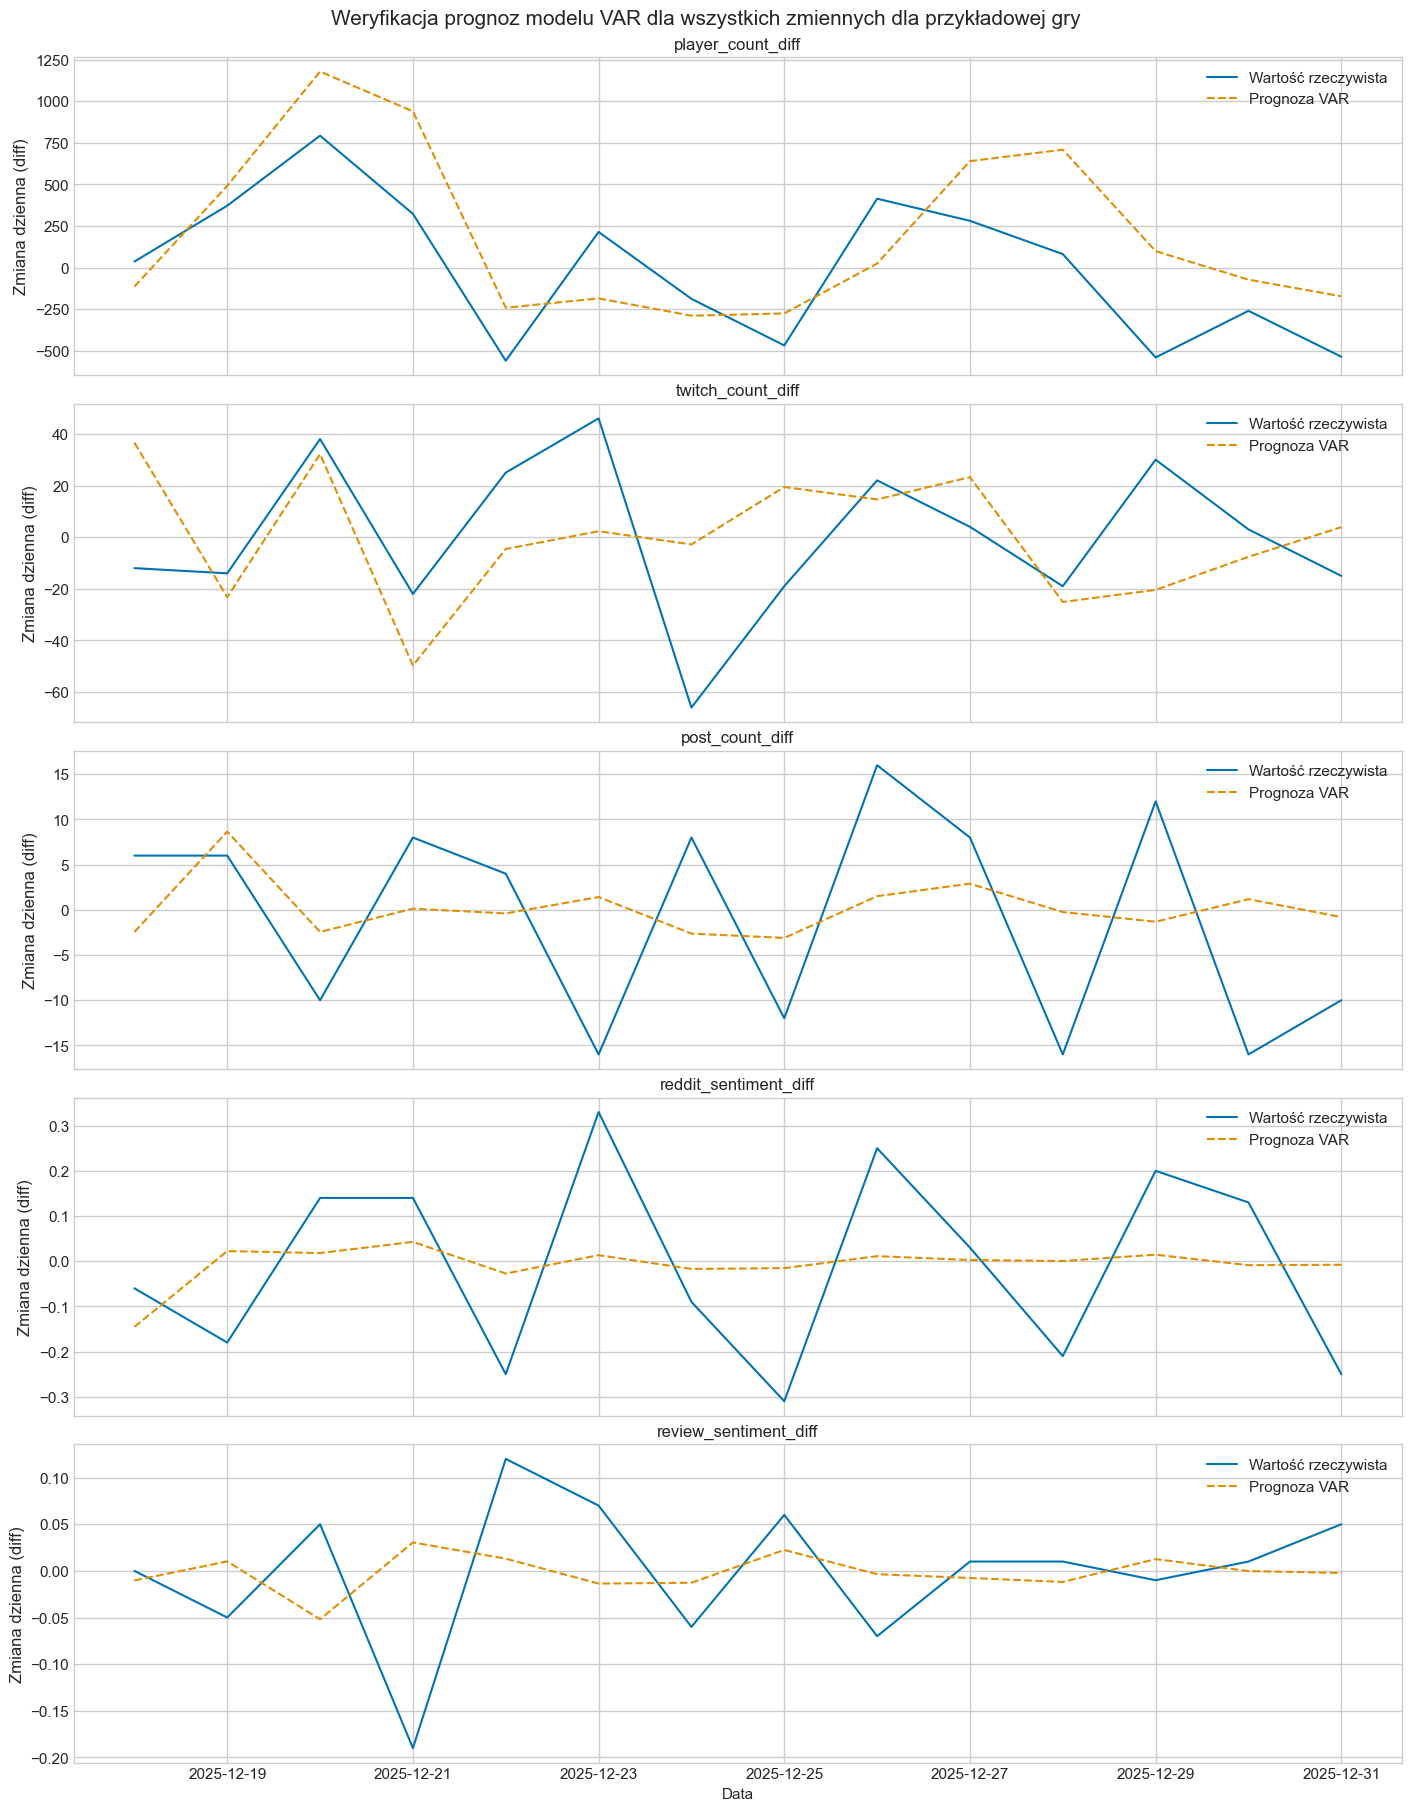

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True, layout = "constrained")

for ax, var in zip(axes, var_metrics):
    ax.plot(
        test.index, 
        test[var], 
        label='Wartość rzeczywista', 
    )

    ax.plot(
        test.index, 
        df_forecast[var], 
        label='Prognoza VAR', 
        linestyle='--', 
    )
    
    ax.set_title(var)
    ax.set_ylabel("Zmiana dzienna (diff)")
    ax.legend()

axes[-1].set_xlabel("Data", fontsize=11)
plt.suptitle("Weryfikacja prognoz modelu VAR dla wszystkich zmiennych dla przykładowej gry", fontsize=15)
plt.show()

In [15]:
error_summary = []

for metric in var_metrics:
    err_rmse = rmse(test[metric], df_forecast[metric])
    err_mae = mean_absolute_error(test[metric], df_forecast[metric])
    error_summary.append({
        'Zmienna': metric,
        'RMSE': round(err_rmse, 4),
        'MAE': round(err_mae, 4)
    })

df_errors = pd.DataFrame(error_summary)
display(df_errors)

,Zmienna,RMSE,MAE
0,player_count_diff,389.4406,346.3629
1,twitch_count_diff,32.7075,27.0669
2,post_count_diff,11.1910,10.2076
3,reddit_sentiment_diff,0.1944,0.1755
4,review_sentiment_diff,0.0817,0.0614


Prognoza wielokrokowa stpsunkowo poprawnie odtworzyła cykliczne wahania liczby graczy (RMSE 389,44; MAE 346,36) oraz ogólny poziom zmienności widowni Twitch (RMSE 32,71) i liczby postów (RMSE 11,19). Z kolei predykcje sentymentu postów (RMSE 0,19) i recenzji (RMSE 0,08) szybko wygasły do zera ze względu na losowy charakter nastrojów i zbieżność modelu do średniej. Wyniki potwierdzają, że modele VAR wychwytują cykliczność zmiennych wolumenowych, lecz mają ograniczoną precyzję punktową dla zaszumionych wskaźników sentymentu, przez co służą głównie do weryfikacji powiązań i przyczynowości, a nie prognozowania.

### 4.5 Limitations and future studies
It is worth noticing that because of the number of games and variables, the Granger tests had to be run thousands of times. Therefore it is very likely that some of them resulted in false positives. Therefore the final results should be taken with a grain of salt. This could be further researched to see whether those analysed relationships can be further explained or justified. As this project was conducted with limited processing power and storage space, some sections of the project such as the sentiment analysis could be expanded to include different filtering of posts or reviews or sentiment analysis using transformer models. The methods used in this project could also be applied to a wider range of games and larger time frames and include other variables in the analysis. Metadata could be used to check whether different types of games have different player activity.